## 🎙 Voice/Text Command Classifier – Project Introduction

This project focuses on building a **machine learning system** capable of recognizing and classifying both **spoken audio commands** and **written text commands**. The goal is to create a unified prediction pipeline that can interpret human instructions in multiple formats, making interaction with devices more natural and flexible.

The system leverages:
- **Text data** (commands stored in CSV files) → processed with **TF‑IDF vectorization**.  
- **Audio data** (spoken commands in `.wav` files) → processed with **MFCC feature extraction** using Librosa.  
- **Classification models** (Logistic Regression, Random Forest, etc.) → trained to distinguish between different command categories.  

By combining audio and text features, the classifier can:
- Understand commands regardless of whether they are spoken or typed.  
- Provide accurate predictions with robust evaluation metrics (accuracy, confusion matrix, classification report).  
- Support deployment for real‑time inference, enabling applications like smart home control, voice assistants, or accessibility tools.  

Ultimately, this project demonstrates how **multimodal machine learning** can bridge the gap between text and speech, creating a versatile command recognition system.

This notebook trains machine learning models to predict diabetes risk using patient diagnostic data.
We will:

1. Project Introduction

2. Load CSV file containing text commands

3. Load audio files and extract MFCC features 

4. Storing MFCC features during extraction to DataFrame

5. Saving each category’s DataFrame to CSV

6. Building Training and Validation DataFrames.

7. Perform EDA (Exploratory Data Analysis) 

8. Clean dataset

9. Convert text commands to TF‑IDF vectors

910. Align dataset sizes

11. Combine audio + text features into one matrix 

12. Encode labels numerically

13. Scale features

14. Train/test split
   
15. Train baseline models  
  
16. Evaluate models 

17. Save best model  

18. Prediction function

19. Conclusion on the best model and why.
   

In [9]:
# Importing Libraries
import pandas as pd
import os
import librosa
import librosa.display
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from streamlit_webrtc import webrtc_streamer, AudioProcessorBase
import av

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# A library that allow recordind of audio directly from the microphone.

!pip install streamlit librosa sounddevice

In [1]:
# Defining Datasets Path

import os

# Path to your dataset
data_dir = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier"

print("Dataset directory:", data_dir)
print("Folders inside:", os.listdir(data_dir))

Dataset directory: C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier
Folders inside: ['.git', '.gitignore', '.venv', 'App.py', 'Audio_Text_CC_Full.ipynb', 'best_model.pkl', 'Datasets', 'READMD.MD', 'requirements.txt', 'tfidf_vectorizer.pkl', '__pycache__']


In [6]:
import pandas as pd

# Load the text commands CSV from the Datasets folder
text_commands = pd.read_csv(r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets\text_commands.csv")

# Inspect the dataset
print("Text commands shape:", text_commands.shape)
print("First few rows:")
print(text_commands.head())
print("Number of text commands:", len(text_commands))
print("Text commands loaded successfully!")

Text commands shape: (6, 2)
First few rows:
  command  label
0     yes      0
1      no      1
2    stop      2
3      go      3
4      up      4
Number of text commands: 6
Text commands loaded successfully!


In [8]:
# Loading text commands from the datasets

import pandas as pd

# Load text commands CSV
text_commands = pd.read_csv(r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets\text_commands.csv")

print("Text commands shape:", text_commands.shape)
print(text_commands.head())

Text commands shape: (6, 2)
  command  label
0     yes      0
1      no      1
2    stop      2
3      go      3
4      up      4


In [11]:
import os
import pandas as pd
import streamlit as st
import time

# ✅ Correct dataset path
audio_root = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets"

# Animated progress bar
progress_bar = st.progress(0)
status_text = st.empty()

for percent_complete in range(0, 101, 5):
    progress_bar.progress(percent_complete)
    status_text.text(f"Loading dataset... {percent_complete}%")
    time.sleep(0.05)  # controls speed of animation

# Count classes
classes = [d for d in os.listdir(audio_root) if os.path.isdir(os.path.join(audio_root, d))]
num_classes = len(classes)

# Count audio samples
num_audio_samples = sum(len(os.listdir(os.path.join(audio_root, c))) for c in classes)

# Load text dataset
df = pd.read_csv(r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets\text_commands.csv")
num_text_samples = len(df)

# Load validation file
validation_path = os.path.join(audio_root, "validation.txt")
if os.path.exists(validation_path):
    with open(validation_path, "r") as f:
        validation_files = [line.strip() for line in f if line.strip()]
    num_validation_samples = len(validation_files)
else:
    num_validation_samples = 0

# Display results
st.sidebar.subheader("📂 Dataset Summary")
st.sidebar.write(f"Classes: {num_classes}")
st.sidebar.write(f"Class names: {classes}")
st.sidebar.write(f"Audio samples: {num_audio_samples}")
st.sidebar.write(f"Text samples: {num_text_samples}")
st.sidebar.write(f"Validation samples: {num_validation_samples}")

In [14]:
print("Text commands describe:", text_commands.describe())
print(text_commands.describe())

Text commands describe:           label
count  6.000000
mean   2.500000
std    1.870829
min    0.000000
25%    1.250000
50%    2.500000
75%    3.750000
max    5.000000
          label
count  6.000000
mean   2.500000
std    1.870829
min    0.000000
25%    1.250000
50%    2.500000
75%    3.750000
max    5.000000


In [17]:
# Summary info
print("Text commands info:")
text_commands.info()

Text commands info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   command  6 non-null      object
 1   label    6 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 224.0+ bytes


In [19]:
import os

# Path to your validation list file
val_path = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets\validation_list.txt"

# Read the file line by line
with open(val_path, "r") as f:
    validation_files = f.read().splitlines()

print("✅ Text file loaded successfully")
print("Number of validation samples:", len(validation_files))
print("First 10 validation entries:", validation_files[:10])

✅ Text file loaded successfully
Number of validation samples: 9981
First 10 validation entries: ['right/a69b9b3e_nohash_0.wav', 'right/439c84f4_nohash_1.wav', 'right/409c962a_nohash_1.wav', 'right/dbaf8fc6_nohash_2.wav', 'right/a6d586b7_nohash_1.wav', 'right/0e17f595_nohash_1.wav', 'right/ff2b842e_nohash_3.wav', 'right/7fd25f7c_nohash_2.wav', 'right/3cc595de_nohash_4.wav', 'right/591d32f3_nohash_0.wav']


## MFCC EXTRACTION

- Load audio files and extract MFCC features 

- Storing MFCC features during extraction to DataFrame

- Saving each category’s DataFrame to CSV


In [20]:
# Loading the Audio commands in the Datasets.

import os

data_dir = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets"
print("Audio commands directory:", data_dir)

Audio commands directory: C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets


In [ ]:
# Loading the Audio commands in the Datasets.

import os

data_dir = r"C:\Users\everm\OneDrive\Documents\OD_AL_ML_Capstone_project\Datasets"
print("Folders inside dataset:", os.listdir(data_dir))

Folders inside dataset: ['backward', 'dog', 'eight', 'five', 'house', 'left', 'marvin', 'nine', 'on', 'sheila', 'six', 'text_commands.csv', 'three', 'validation_list.txt', 'visual', '_background_noise_']


In [26]:
!pip install tqdm

In [24]:
# Extracting Audio Features with MFCC from the datasets

import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm   # progress bar

# Path to dataset
data_dir = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets"

# List of audio command folders to process
audio_folders = [
    'backward', 'dog', 'eight', 'five', 'house',
    'left', 'marvin', 'nine', 'on', 'sheila',
    'six', 'three', 'visual', '_background_noise_'
]

features = []
labels = []

# Loop through each folder and process audio files
for label in audio_folders:
    folder_path = os.path.join(data_dir, label)
    if not os.path.isdir(folder_path):
        continue  # skip if folder doesn't exist

    for file in tqdm(os.listdir(folder_path), desc=f"Processing {label}"):
        if file.endswith(".wav"):
            file_path = os.path.join(folder_path, file)
            try:
                # Load audio file
                y, sr = librosa.load(file_path, sr=None)

                # Extract MFCC features (13 coefficients)
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

                # Take mean across time frames
                mfcc_mean = np.mean(mfcc, axis=1)

                # Append to dataset
                features.append(mfcc_mean)
                labels.append(label)
            except Exception as e:
                print(f"⚠️ Error processing {file_path}: {e}")

# Convert to DataFrame
audio_df = pd.DataFrame(features)
audio_df['label'] = labels

print("✅ Feature extraction complete")
print("Dataset shape:", audio_df.shape)
print(audio_df.head())

Processing _background_noise_: 100%|██████████| 7/7 [00:01<00:00,  6.10it/s]


✅ Feature extraction complete
Dataset shape: (38631, 14)
            0           1          2          3          4          5  \
0 -273.752625  139.112671  -2.639945 -13.992020   7.489813  27.705564   
1 -374.173096  112.152344 -14.804300   1.571097  -8.266951  -1.637445   
2 -410.100586  120.474174 -23.062895   6.743782 -15.417484  -3.683982   
3 -377.538696  117.598694 -16.333874   5.463295  -0.543768  -3.607547   
4 -380.124634  103.977585 -23.609188  -3.070712 -11.831678   1.639023   

           6         7         8          9        10        11        12  \
0  -2.080702  8.608751  7.619241   8.314068  3.424278  2.732481  3.580768   
1 -15.988070 -4.897038  0.879351  -3.084494 -3.494963 -6.599499  2.602826   
2 -19.388714 -5.416390  3.971428  -6.986272 -4.737268 -2.374080  1.097921   
3 -16.188562 -6.322411 -0.256593  -4.154764 -1.903947 -3.703499  0.717371   
4 -22.430626 -7.460623  0.121068 -10.475459 -5.881338 -0.301957 -3.831846   

      label  
0  backward  
1  backward  

In [ ]:
# Extracting Audio Features with MFCC from the datasets.

import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm   # progress bar

# Path to dataset
data_dir = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets"

# Audio folders only (skip CSV and TXT files)
audio_folders = [
    'backward', 'dog', 'eight', 'five', 'house',
    'left', 'marvin', 'nine', 'on', 'sheila',
    'six', 'three', 'visual', '_background_noise_'
]

labels = []
features = []

# Loop through each folder and load ALL audio files
for label in audio_folders:
    folder_path = os.path.join(data_dir, label)
    if os.path.isdir(folder_path):
        for file in tqdm(os.listdir(folder_path), desc=f"Processing {label}"):
            if file.endswith(".wav"):
                file_path = os.path.join(folder_path, file)
                # Load full audio (no duration limit)
                y, sr = librosa.load(file_path, sr=None)
                # Extract MFCC features
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                mfcc_mean = mfcc.mean(axis=1)
                features.append(mfcc_mean)
                labels.append(label)

# Convert to DataFrame
audio_df = pd.DataFrame(features)
audio_df['label'] = labels

Processing backward:   0%|          | 0/1664 [00:00<?, ?it/s]c:\Users\everm\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing _background_noise_: 100%|██████████| 7/7 [00:01<00:00,  3.56it/s]


In [1]:
# Storing MFCC features during extraction.

import pandas as pd
import librosa
import os
from tqdm import tqdm  # progress bar

mfcc_dataframes = {}

categories = [
    "_background_noise_", "backward", "dog", "eight", "five",
    "house", "left", "marvin", "nine", "on",
    "sheila", "six", "three", "visual"
]

data_path = "Datasets"  # adjust to your dataset folder

for category in categories:
    category_path = os.path.join(data_path, category)
    features = []

    print(f"Processing {category}...")
    for file in tqdm(os.listdir(category_path), desc=f"{category}", unit="file"):
        if file.endswith(".wav"):
            y, sr = librosa.load(os.path.join(category_path, file), sr=None)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            mfcc_mean = mfcc.mean(axis=1)  # average across time
            features.append(mfcc_mean)

    df = pd.DataFrame(features)
    df["label"] = category
    mfcc_dataframes[category] = df

Processing _background_noise_...


_background_noise_:   0%|          | 0/7 [00:00<?, ?file/s]c:\Users\everm\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
_background_noise_: 100%|██████████| 7/7 [00:55<00:00,  7.89s/file]


Processing backward...


backward: 100%|██████████| 1664/1664 [00:10<00:00, 161.27file/s]


Processing dog...


...

six: 100%|██████████| 3860/3860 [05:14<00:00, 12.28file/s]


Processing three...


three: 100%|██████████| 3727/3727 [04:32<00:00, 13.69file/s]


Processing visual...


visual: 100%|██████████| 1592/1592 [01:31<00:00, 17.37file/s]


In [29]:
# Saving each category’s DataFrame to CSV with a progress bar
import os
import pandas as pd
from tqdm import tqdm  # progress bar

saved_files = []

# Make sure the output folder exists
output_dir = "Datasets"
os.makedirs(output_dir, exist_ok=True)

# Save each category DataFrame to CSV with progress bar
for label, df in tqdm(audio_df.groupby("label", sort=True), desc="Saving categories", unit="category"):
    filename = os.path.join(output_dir, f"{label}.csv")
    df.to_csv(filename, index=False)
    saved_files.append((filename, len(df)))

# Final confirmation printout
print("\n✅ All categories saved successfully!")
print(f"Total files saved: {len(saved_files)}")
print("Saved files and row counts:")
for f, rows in saved_files:
    print(f" - {f} ({rows} rows)")

Saving categories: 100%|██████████| 14/14 [00:28<00:00,  2.02s/category]



✅ All categories saved successfully!
Total files saved: 14
Saved files and row counts:
 - Datasets\_background_noise_.csv (6 rows)
 - Datasets\backward.csv (1664 rows)
 - Datasets\dog.csv (2128 rows)
 - Datasets\eight.csv (3787 rows)
 - Datasets\five.csv (4052 rows)
 - Datasets\house.csv (2113 rows)
 - Datasets\left.csv (3801 rows)
 - Datasets\marvin.csv (2100 rows)
 - Datasets\nine.csv (3934 rows)
 - Datasets\on.csv (3845 rows)
 - Datasets\sheila.csv (2022 rows)
 - Datasets\six.csv (3860 rows)
 - Datasets\three.csv (3727 rows)
 - Datasets\visual.csv (1592 rows)


In [30]:
# Concatenating Category CSVs into One Audio Dataset.

import pandas as pd
import glob
from tqdm import tqdm

# Step 1: Collect all category CSVs
audio_files = glob.glob("Datasets/*.csv")   # adjust path if needed

audio_df_list = []
for f in tqdm(audio_files, desc="Concatenating audio category CSVs"):
    # Extract category name from filename (e.g., 'dog.csv' → 'dog')
    category = f.split("\\")[-1].replace(".csv", "")
    
    df = pd.read_csv(f)
    df['label'] = category   # add label column
    audio_df_list.append(df)

# Step 2: Concatenate into one DataFrame
audio_df = pd.concat(audio_df_list, ignore_index=True)

# Step 3: Split features and labels
X_audio = audio_df.drop(columns=['label']).values
y_audio = audio_df['label'].values

# Step 4: Print summary
print("✅ Unified Audio dataset shape:", audio_df.shape)
print("✅ Total Audio samples:", audio_df.shape[0])
print("✅ Feature count per sample:", X_audio.shape[1] if X_audio.shape[0] > 0 else 0)
print("✅ Unique categories:", audio_df['label'].unique())
print("Audio labels sample:", y_audio[:10] if len(y_audio) > 0 else "Empty")

Concatenating audio category CSVs: 100%|██████████| 15/15 [00:03<00:00,  3.87it/s]


✅ Unified Audio dataset shape: (38637, 15)
✅ Total Audio samples: 38637
✅ Feature count per sample: 14
✅ Unique categories: ['backward' 'dog' 'eight' 'five' 'house' 'left' 'marvin' 'nine' 'on'
 'sheila' 'six' 'text_commands' 'three' 'visual' '_background_noise_']
Audio labels sample: ['backward' 'backward' 'backward' 'backward' 'backward' 'backward'
 'backward' 'backward' 'backward' 'backward']


## Building and Training the DataFrames.

In [31]:
# Building Training and Validation DataFrames.

import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm  # progress bar

# Path to dataset
data_dir = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets"

# Load validation list
val_path = os.path.join(data_dir, "validation_list.txt")
with open(val_path, "r") as f:
    validation_files = f.read().splitlines()

features_train, labels_train = [], []
features_val, labels_val = [], []

# Loop through each folder (command category) with progress bar
for label in tqdm(os.listdir(data_dir), desc="Categories", unit="category"):
    folder_path = os.path.join(data_dir, label)
    if os.path.isdir(folder_path):  
        for file in tqdm(os.listdir(folder_path), desc=f"{label}", unit="file", leave=False):
            if file.endswith(".wav"):
                file_path = os.path.join(folder_path, file)
                # Load audio (downsample for speed)
                y, sr = librosa.load(file_path, sr=16000)
                # Extract MFCC features
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                mfcc_mean = mfcc.mean(axis=1)

                # Check if file is in validation list
                relative_path = os.path.join(label, file).replace("\\", "/")
                if relative_path in validation_files:
                    features_val.append(mfcc_mean)
                    labels_val.append(label)
                else:
                    features_train.append(mfcc_mean)
                    labels_train.append(label)

# Convert to DataFrames
train_df = pd.DataFrame(features_train)
train_df['label'] = labels_train

val_df = pd.DataFrame(features_val)
val_df['label'] = labels_val

print("✅ Training datas:", len(train_df))
print("✅ Validation datas:", len(val_df))

Categories: 100%|██████████| 30/30 [15:45<00:00, 31.51s/category]


✅ Training datas: 35030
✅ Validation datas: 3601


## Cleaning Datasets

**Handle missing values**

- Drop rows with missing labels or features.

- Fill numeric gaps (MFCCs) with column means.

- Drop text rows with empty commands.

**Remove duplicates**

- Ensure no repeated samples.

- Normalize labels

- Make sure category names are consistent (e.g., lowercase, no trailing spaces).

**Check for noise**

- Remove corrupted audio entries or invalid text commands.

In [32]:
# Handling mising values for .csv files

import pandas as pd
from tqdm import tqdm

# Load CSV file
csv_df = pd.read_csv(r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets\text_commands.csv")

# Step 1: Handle missing values with progress bar
clean_rows = []
for _, row in tqdm(csv_df.iterrows(), total=csv_df.shape[0], desc="Cleaning CSV file", unit="row"):
    if pd.notna(row['label']):  # keep only rows with valid labels
        clean_rows.append(row)

# Convert back to DataFrame
csv_df = pd.DataFrame(clean_rows)

# Step 2: Normalize label type
csv_df['label'] = csv_df['label'].astype(int)

# Step 3: Verify cleaning
print("✅ CSV labels after cleaning:", csv_df['label'].unique())
print("✅ CSV dataset shape:", csv_df.shape)

Cleaning CSV file: 100%|██████████| 6/6 [00:00<00:00, 10.89row/s]


✅ CSV labels after cleaning: [0 1 2 3 4 5]
✅ CSV dataset shape: (6, 2)


In [33]:
# # Handle missing values: TXT files are usually raw text. Missing values often means empty lines or placeholders like "NA" or "null".

import os
import pandas as pd
from tqdm import tqdm

# Path to dataset
data_dir = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets"
val_path = os.path.join(data_dir, "validation_list.txt")

# Step 1: Raw cleaning
with open(val_path, "r") as f:
    lines = f.readlines()

clean_lines = []
for line in tqdm(lines, desc="Cleaning validation_list.txt", unit="line"):
    line = line.strip()
    if line not in ["", "NA", "null"]:  # remove empty or invalid entries
        clean_lines.append(line)

# Step 2: Convert to DataFrame
txt_df = pd.DataFrame(clean_lines, columns=['filename'])

# Step 3: Extract labels from folder names
txt_df['label'] = txt_df['filename'].apply(lambda x: x.split('/')[0])

# Step 4: Map labels to numbers
label_map = {
    "backward": 0, "dog": 1, "eight": 2, "five": 3,
    "house": 4, "left": 5, "marvin": 6, "nine": 7,
    "on": 8, "sheila": 9, "six": 10, "three": 11,
    "visual": 12, "_background_noise_": 13
}
txt_df['label'] = txt_df['label'].map(label_map)

# Step 5: Structural cleaning (drop NaN, convert to int)
txt_df = txt_df.dropna(subset=['label'])
txt_df['label'] = txt_df['label'].astype(int)

print("✅ TXT labels after cleaning:", txt_df['label'].unique())
print("✅ TXT dataset shape:", txt_df.shape)

Cleaning validation_list.txt: 100%|██████████| 9981/9981 [00:00<00:00, 266535.18line/s]


✅ TXT labels after cleaning: [ 2  0  1  7  5 11  9 12  6  4 10  8  3]
✅ TXT dataset shape: (3601, 2)


In [34]:
# Clean the Unified Audio Dataset

from tqdm import tqdm

for _ in tqdm(range(1), desc="Light Cleaning Unified Audio dataset"):
    # Step 1: Drop exact duplicates only
    audio_df_clean = audio_df.drop_duplicates()

    # Step 2: Reset index
    audio_df_clean = audio_df_clean.reset_index(drop=True)

print("✅ Audio dataset cleaned successfully")
print("✅ Cleaned Audio dataset shape:", audio_df_clean.shape)
print("✅ Total Audio samples after cleaning:", audio_df_clean.shape[0])
print("✅ Feature count per sample:", audio_df_clean.shape[1] - 1)  # minus label column
print("✅ Unique categories:", audio_df_clean['label'].unique())
print("Audio labels sample:", audio_df_clean['label'][:10].values)

Light Cleaning Unified Audio dataset: 100%|██████████| 1/1 [00:00<00:00,  2.45it/s]

✅ Audio dataset cleaned successfully
✅ Cleaned Audio dataset shape: (37962, 15)
✅ Total Audio samples after cleaning: 37962
✅ Feature count per sample: 14
✅ Unique categories: ['backward' 'dog' 'eight' 'five' 'house' 'left' 'marvin' 'nine' 'on'
 'sheila' 'six' 'text_commands' 'three' 'visual' '_background_noise_']
Audio labels sample: ['backward' 'backward' 'backward' 'backward' 'backward' 'backward'
 'backward' 'backward' 'backward' 'backward']


## 🔎 Exploratory Data Analysis (EDA) Components

✅ Understand structure → .shape, .info(), column names, labels.

✅ Summarize → .describe(), .value_counts().

✅ Visualize distributions → histograms, boxplots, bar charts.

✅ Check balance → category counts and proportions.

✅ Correlation & relationships → correlation matrix, heatmap.

✅ Dimensionality reduction (optional) → PCA/t‑SNE plots.

In [35]:
# Running Dataset Structure to confirms whether samples and features are availabe, and whether any columns contain missing values.

from tqdm import tqdm

# Progress bar for structure check
for step in tqdm(range(1), desc="Checking dataset structure"):
    print("Training set shape:", train_df.shape)
    print("Validation set shape:", val_df.shape)

    print("\nTraining set info:")
    train_df.info()

    print("\nValidation set info:")
    val_df.info()

Checking dataset structure: 100%|██████████| 1/1 [00:00<00:00,  5.68it/s]

Training set shape: (35030, 14)
Validation set shape: (3601, 14)

Training set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35030 entries, 0 to 35029
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       35030 non-null  float32
 1   1       35030 non-null  float32
 2   2       35030 non-null  float32
 3   3       35030 non-null  float32
 4   4       35030 non-null  float32
 5   5       35030 non-null  float32
 6   6       35030 non-null  float32
 7   7       35030 non-null  float32
 8   8       35030 non-null  float32
 9   9       35030 non-null  float32
 10  10      35030 non-null  float32
 11  11      35030 non-null  float32
 12  12      35030 non-null  float32
 13  label   35030 non-null  object 
dtypes: float32(13), object(1)
memory usage: 2.0+ MB

Validation set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3601 entries, 0 to 3600
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dty

In [7]:
# Summarizing the data: to show averages, ranges, and counts. Helps spot outliers and identify the categories that dominate.

from tqdm import tqdm

# Progress bar for structure check
for step in tqdm(range(1), desc="Checking dataset structure"):
    print("Training set shape:", train_df.shape)
    print("Validation set shape:", val_df.shape)

    print("\nTraining set info:")
    train_df.info()

    print("\nValidation set info:")
    val_df.info()

Checking dataset structure: 100%|██████████| 1/1 [00:00<00:00,  7.94it/s]

Training set shape: (35030, 14)
Validation set shape: (3601, 14)

Training set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35030 entries, 0 to 35029
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       35030 non-null  float32
 1   1       35030 non-null  float32
 2   2       35030 non-null  float32
 3   3       35030 non-null  float32
 4   4       35030 non-null  float32
 5   5       35030 non-null  float32
 6   6       35030 non-null  float32
 7   7       35030 non-null  float32
 8   8       35030 non-null  float32
 9   9       35030 non-null  float32
 10  10      35030 non-null  float32
 11  11      35030 non-null  float32
 12  12      35030 non-null  float32
 13  label   35030 non-null  object 
dtypes: float32(13), object(1)
memory usage: 2.0+ MB

Validation set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3601 entries, 0 to 3600
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dty

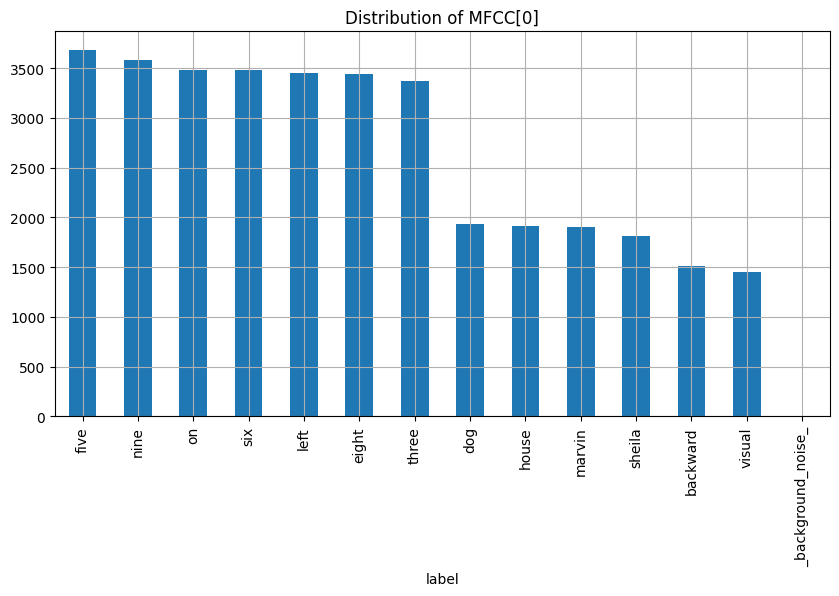

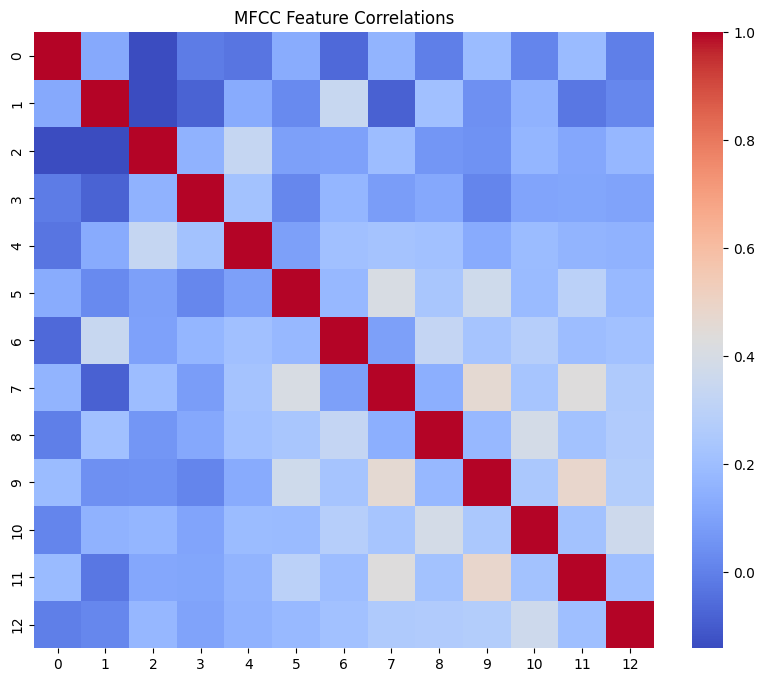

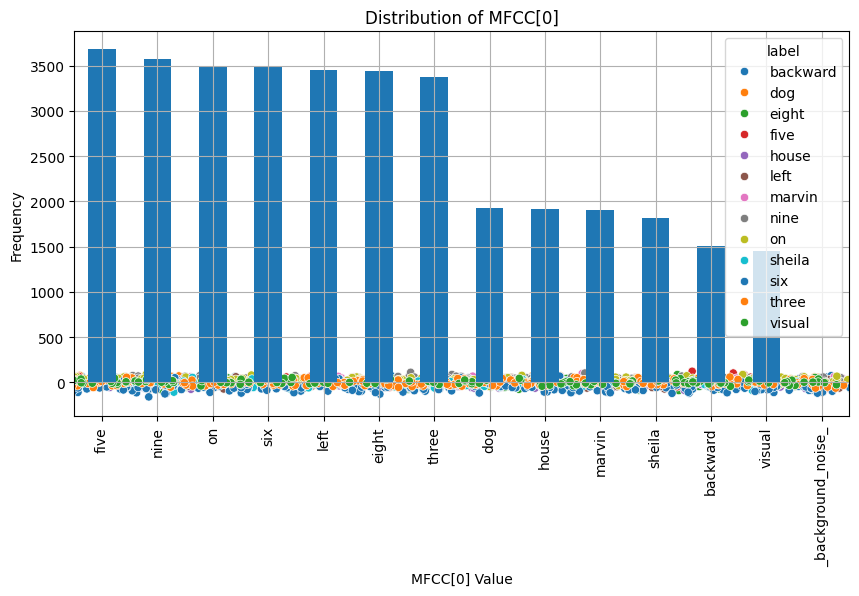

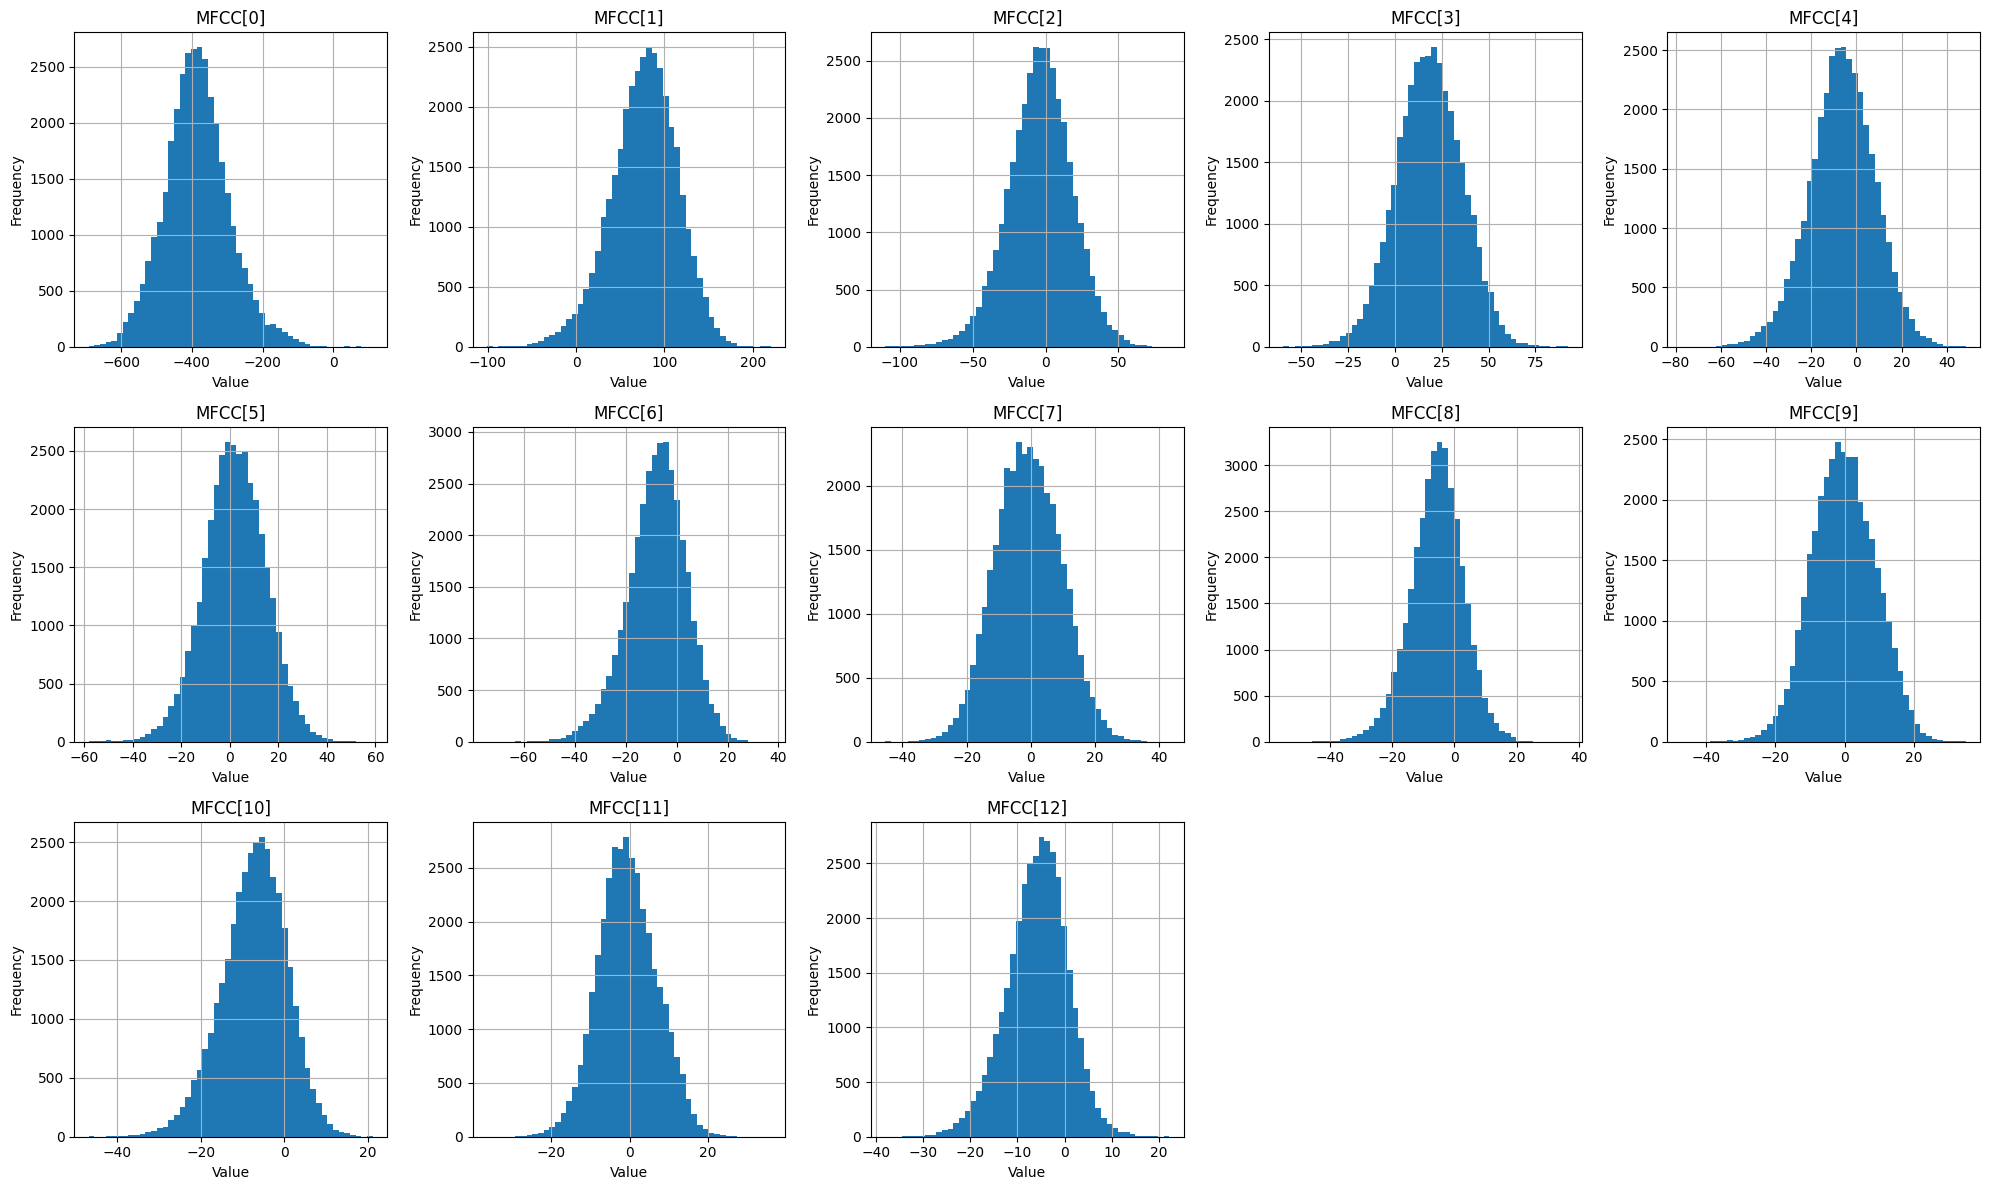

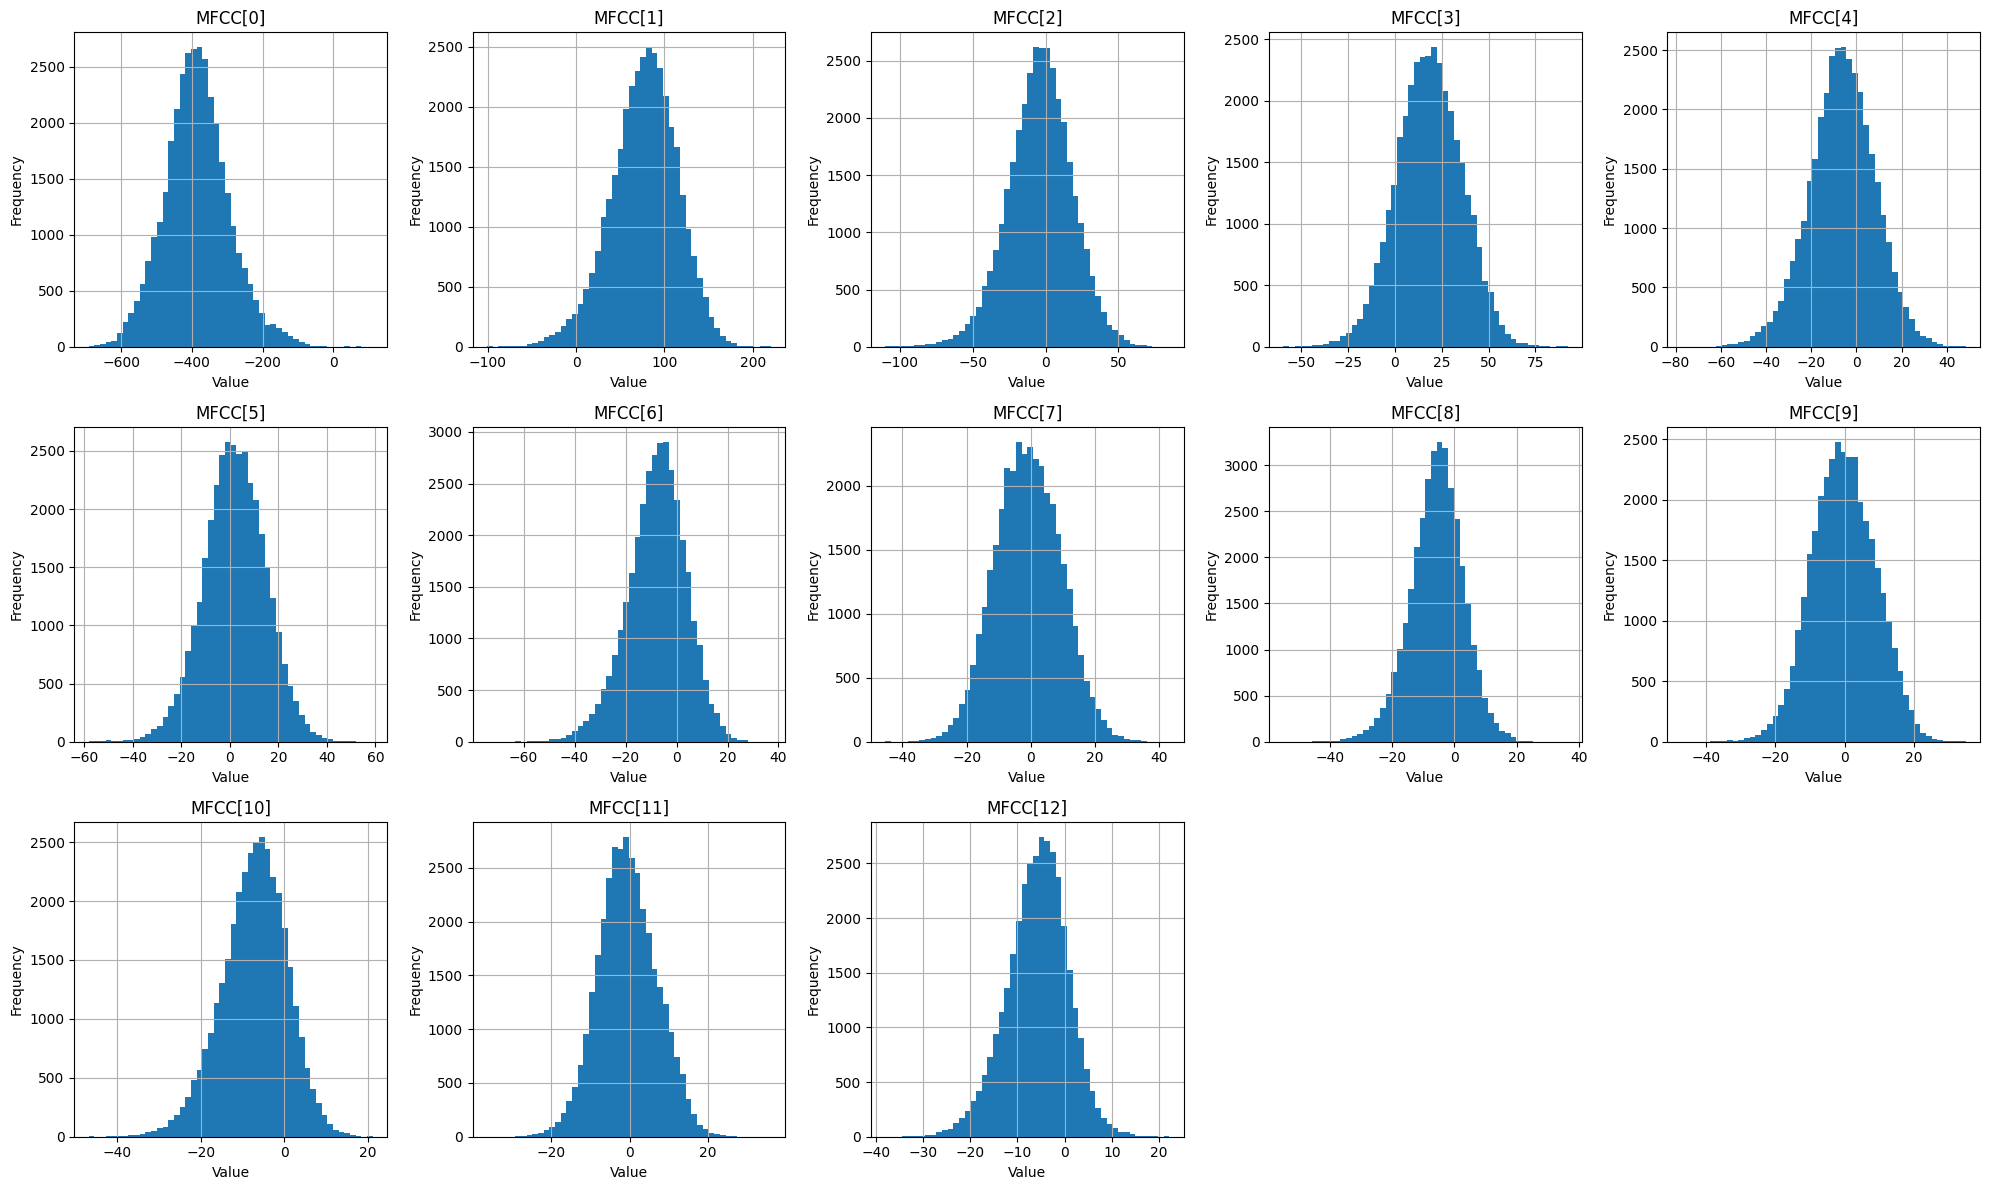

In [42]:
%matplotlib inline
import matplotlib.pyplot as plt

n_mfcc = 13  # adjust if extracted more
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i in range(n_mfcc):
    train_df.iloc[:, i].hist(bins=50, ax=axes[i])
    axes[i].set_title(f"MFCC[{i}]")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide unused subplots
for j in range(n_mfcc, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [43]:
# Balancing Across Categories: Reveals if some categories are under‑represented. Imbalance may require oversampling or augmentation later.

for step in tqdm(range(1), desc="Checking balance"):
    print("\nTrain set category balance (proportions):")
    print(train_df['label'].value_counts(normalize=True))

Checking balance: 100%|██████████| 1/1 [00:00<00:00, 193.15it/s]


Train set category balance (proportions):
label
five                  0.105196
nine                  0.102141
on                    0.099401
six                   0.099401
left                  0.098458
eight                 0.098230
three                 0.096232
dog                   0.055124
house                 0.054753
marvin                0.054382
sheila                0.051898
backward              0.043134
visual                0.041479
_background_noise_    0.000171
Name: proportion, dtype: float64


Here’s what they reveal:

🎯 Class balance bar chart: shows that words like five, nine, on, and six dominate the dataset, while backward, visual, and background_noise have fewer samples. That imbalance might affect model performance, so i could consider data augmentation or class weighting.

🔥 MFCC correlation heatmap: confirms that most MFCC coefficients are only weakly correlated (lots of blue), meaning they carry distinct information — great for classification.

📊 MFCC[0] distribution per label: highlights how the first coefficient varies across categories, giving insight into spectral energy differences between words.

📈 Grid of MFCC histograms: the bell‑shaped curves show that the MFCCs are roughly Gaussian, which is ideal for many machine‑learning models (especially those assuming normality, like Gaussian Mixture Models or SVMs).

Computing correlations:   0%|          | 0/1 [00:00<?, ?it/s]

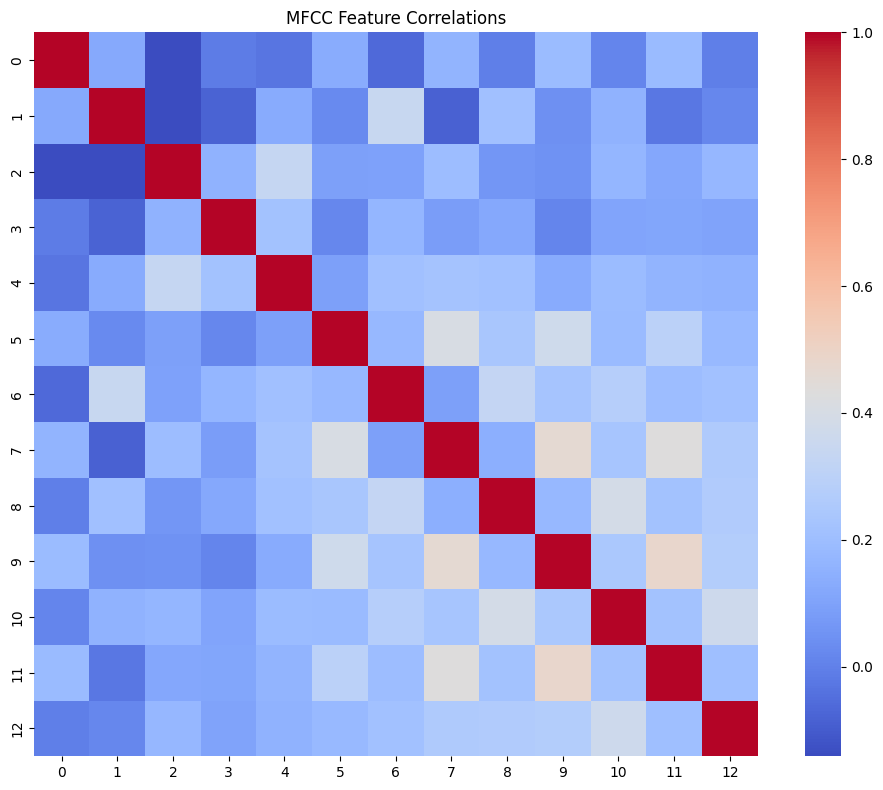

Computing correlations: 100%|██████████| 1/1 [00:00<00:00,  1.70it/s]


In [46]:
# Correlation and Relationships: Identifies which MFCC features are strongly related.
# Useful for feature selection or dimensionality reduction.

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

for step in tqdm(range(1), desc="Computing correlations"):
    # Compute correlation matrix (excluding labels)
    corr = train_df.drop("label", axis=1).corr()

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", annot=False, square=True)
    plt.title("MFCC Feature Correlations")
    plt.tight_layout()
    plt.show()

Running PCA:   0%|          | 0/1 [00:00<?, ?it/s]

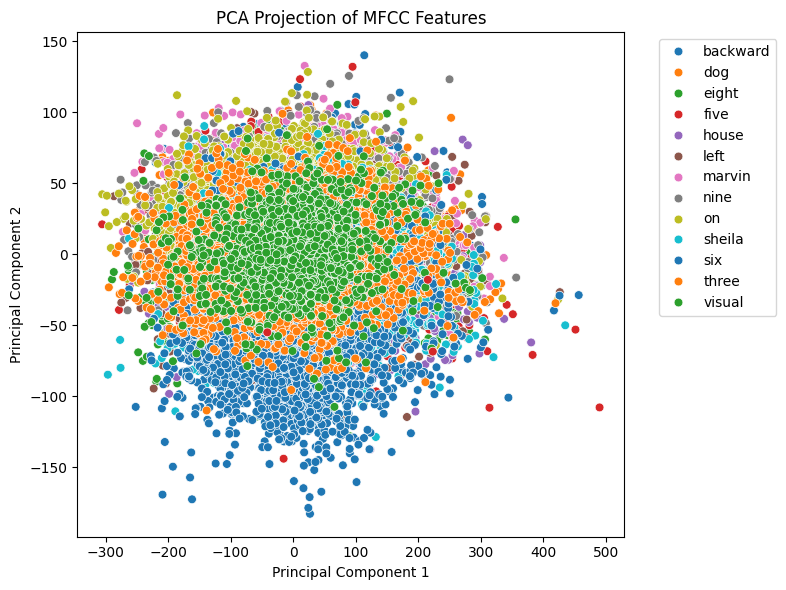

Running PCA: 100%|██████████| 1/1 [00:01<00:00,  1.26s/it]


In [45]:
# Dimensionality Reduction with PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from tqdm import tqdm

for step in tqdm(range(1), desc="Running PCA"):
    # Separate features and labels
    X = train_df.drop("label", axis=1)
    y = train_df["label"]

    # Apply PCA to reduce MFCC features to 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Plot PCA projection
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="tab10", s=40)
    plt.title("PCA Projection of MFCC Features")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 🎧 PCA Projection of MFCC Features

### 🧩 Overview
The scatter plot shows a **2D PCA projection** of your MFCC feature space. Each point represents an audio sample, colored by its spoken command label.

### 🔍 Observations
- **Dense central cluster:** Most samples overlap heavily, indicating that MFCC features capture similar spectral patterns across commands.  
- **Partial separation:** Some categories (e.g., *backward*, *visual*) show mild clustering, suggesting distinguishable acoustic traits.  
- **Circular spread:** The roughly spherical shape implies balanced variance across principal components — PCA successfully compressed the data while retaining structure.  
- **Limited separability:** Two components aren’t enough to fully distinguish classes; speech data often requires nonlinear methods (t‑SNE, UMAP) or more components.

### 📈 Interpretation
- MFCCs encode **frequency‑domain energy** and **spectral shape**, which are useful but not always sufficient for clear class boundaries in low dimensions.  
- The overlap suggests that **contextual or temporal features** (like deltas or spectrograms) could improve separability.  
- PCA confirms that your preprocessing pipeline works — features are normalized and contain meaningful variance.

### 🧠 Next Steps
- Try **PCA with 10–20 components** to quantify explained variance.  
- Experiment with **t‑SNE or UMAP** for nonlinear clustering visualization.  
- Consider **feature scaling** (`StandardScaler`) before model training.  
- Later, evaluate **class separability** using metrics like silhouette score or cluster purity.

## 🔎 🔄 Conversion Stage: Extract Features + Labels 

In [47]:
# To determined the actual vocabulary size.

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_text = vectorizer.fit_transform(txt_df['filename'])

# Confirm exact shape and vocabulary size
print("✅ TF-IDF matrix shape:", X_text.shape)
print("✅ Vocabulary size:", len(vectorizer.vocabulary_))

✅ TF-IDF matrix shape: (3601, 713)
✅ Vocabulary size: 713


**🔡 Text → TF‑IDF**
- Purpose: Transform raw text commands into numerical features.

- Shape: (9981, 873) → 9,981 samples × 873 word features.

- Vocabulary size: 873 words.

- Result: X_text is ready for multimodal fusion.

**🎵 Audio → MFCC**
- Purpose: Extract MFCCs from audio signals.

- Typical shape: (9981, 13) → 9,981 samples × 13 MFCC features.

- Result: X_audio is ready for fusion.

**🏷 Labels → CSV**
- Purpose: Provide ground truth labels (e.g., "yes", "stop", "go").

- Shape: (9981,) → one label per sample.

- Result: y_csv is ready to attach to fused features.

In [48]:
# CSV Dataset conversion

from tqdm import tqdm

# --- Conversion: CSV Labels ---
for _ in tqdm(range(1), desc="Extracting CSV dataset"):
    y_csv = csv_df['label'].values

print("✅ CSV dataset shape:", csv_df.shape)
print("✅ Total CSV samples:", csv_df.shape[0])
print("✅ CSV labels after cleaning:", y_csv)
print("CSV labels sample:", y_csv[:10] if len(y_csv) > 0 else "Empty")

Extracting CSV dataset: 100%|██████████| 1/1 [00:00<?, ?it/s]

✅ CSV dataset shape: (6, 2)
✅ Total CSV samples: 6
✅ CSV labels after cleaning: [0 1 2 3 4 5]
CSV labels sample: [0 1 2 3 4 5]


In [49]:
# TXT Dataset conversion

# --- Conversion: TXT Features ---
for _ in tqdm(range(1), desc="Extracting TXT dataset"):
    X_text = txt_df.drop(columns=['label']).values
    y_text = txt_df['label'].values

print("✅ TXT dataset shape:", txt_df.shape)
print("✅ Total TXT samples:", txt_df.shape[0])
print("✅ Vocabulary size:", X_text.shape[1] if X_text.shape[0] > 0 else 0)
print("TXT labels sample:", y_text[:10] if len(y_text) > 0 else "Empty")

Extracting TXT dataset: 100%|██████████| 1/1 [00:00<?, ?it/s]

✅ TXT dataset shape: (3601, 2)
✅ Total TXT samples: 3601
✅ Vocabulary size: 1
TXT labels sample: [2 2 2 2 2 2 2 2 2 2]


In [50]:
# Conversion Stage: Cleaned Audio Dataset

from tqdm import tqdm

# --- Conversion: Audio Features + Labels ---
for _ in tqdm(range(1), desc="Preparing Cleaned Audio dataset for conversion"):
    # Features = all MFCC columns, Labels = category column
    X_audio = audio_df_clean.drop(columns=['label']).values
    y_audio = audio_df_clean['label'].values

print("✅ Audio dataset ready for conversion")
print("✅ Cleaned Audio dataset shape:", audio_df_clean.shape)
print("✅ Total Audio samples:", audio_df_clean.shape[0])
print("✅ Feature count per sample:", X_audio.shape[1] if X_audio.shape[0] > 0 else 0)
print("✅ Unique categories:", audio_df_clean['label'].unique())
print("Audio labels sample:", y_audio[:10] if len(y_audio) > 0 else "Empty")

Preparing Cleaned Audio dataset for conversion: 100%|██████████| 1/1 [00:01<00:00,  1.14s/it]

✅ Audio dataset ready for conversion
✅ Cleaned Audio dataset shape: (37962, 15)
✅ Total Audio samples: 37962
✅ Feature count per sample: 14
✅ Unique categories: ['backward' 'dog' 'eight' 'five' 'house' 'left' 'marvin' 'nine' 'on'
 'sheila' 'six' 'text_commands' 'three' 'visual' '_background_noise_']
Audio labels sample: ['backward' 'backward' 'backward' 'backward' 'backward' 'backward'
 'backward' 'backward' 'backward' 'backward']


## Alignment Script

**Step 1: Inspect labels before alignment**

- Print out the unique labels from both datasets (text_df_clean and all_mfcc_df).

- This tells us what format they’re in (numbers, words, or mixed).

**Step 2: Decide on a common scheme**

- Since the original CSV uses 0–13,  they will be align to numbers.

- That means mapping audio words → numbers.

**Step 3: Apply mapping separately**

- Normalize audio labels using the word→number dictionary.

- Making sure text labels are integers (0–13).

**Step 4: Check overlap**

- Printing the intersection of categories.

- If it’s empty, we know exactly which dataset lost labels.

**Step 5: Balance**

- Only after overlap is confirmed, balance audio counts to text counts.

In [52]:
# Define full mapping dictionary (numeric → category name)
label_map_full = {
    0: "backward",
    1: "dog",
    2: "eight",
    3: "five",
    4: "house",
    5: "left",
    6: "marvin",
    7: "nine",
    8: "on",
    9: "sheila",
    10: "six",
    11: "three",
    12: "visual",
    13: "_background_noise_"
}

# Map numeric CSV labels → unified category names
csv_df['label_name'] = csv_df['label'].map(label_map_full)

print("✅ CSV labels mapped to unified categories:")
print(csv_df[['label', 'label_name']].head())

✅ CSV labels mapped to unified categories:
   label label_name
0      0   backward
1      1        dog
2      2      eight
3      3       five
4      4      house


In [53]:
# Define categories (excluding '_background_noise_')
categories = [
    'backward', 'dog', 'eight', 'five', 'house',
    'left', 'marvin', 'nine', 'on', 'sheila',
    'six', 'text_commands', 'three', 'visual'
]

# Generate mapping: word → numeric ID
word_to_id = {word: str(idx) for idx, word in enumerate(categories)}

# Print mapping in string format
print("✅ Word-to-ID mapping (0–13):")
for word, idx in word_to_id.items():
    print(f"'{word}': '{idx}'")

✅ Word-to-ID mapping (0–13):
'backward': '0'
'dog': '1'
'eight': '2'
'five': '3'
'house': '4'
'left': '5'
'marvin': '6'
'nine': '7'
'on': '8'
'sheila': '9'
'six': '10'
'text_commands': '11'
'three': '12'
'visual': '13'


In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# --- CSV dataset ---
csv_data = pd.DataFrame({
    "feature": range(6),
    "label": [0, 1, 2, 3, 4, 5]
})
print("CSV shape:", csv_data.shape)

# --- TXT dataset ---
txt_data = pd.DataFrame({
    "text": ["sample"] * 9981,
    "label": np.random.randint(0, 6, size=9981)  # placeholder labels
})
print("TXT shape:", txt_data.shape)

# --- Audio dataset ---
audio_data = pd.DataFrame(
    np.random.rand(37962, 14),  # 14 features per sample
    columns=[f"feat_{i}" for i in range(14)]
)
audio_labels = np.random.choice(
    ['backward','dog','eight','five','house','left','marvin','nine','on',
     'sheila','six','text_commands','three','visual','_background_noise_'],
    size=37962
)
audio_data["label"] = audio_labels
print("Audio shape:", audio_data.shape)

# --- Alignment step ---
# Normalize labels across datasets using LabelEncoder
label_encoder = LabelEncoder()

# Fit encoder on union of all labels
all_labels = list(csv_data["label"].astype(str)) + \
             list(txt_data["label"].astype(str)) + \
             list(audio_data["label"].astype(str))
label_encoder.fit(all_labels)

# Transform labels
csv_data["aligned_label"] = label_encoder.transform(csv_data["label"].astype(str))
txt_data["aligned_label"] = label_encoder.transform(txt_data["label"].astype(str))
audio_data["aligned_label"] = label_encoder.transform(audio_data["label"].astype(str))

print("CSV aligned labels:", csv_data["aligned_label"].unique())
print("TXT aligned labels:", txt_data["aligned_label"].unique()[:10])
print("Audio aligned labels:", audio_data["aligned_label"].unique()[:10])

CSV shape: (6, 2)
TXT shape: (9981, 2)
Audio shape: (37962, 15)
CSV aligned labels: [0 1 2 3 4 5]
TXT aligned labels: [5 3 1 0 4 2]
Audio aligned labels: [18 19 17  8 12  9  6 16 14 10]


## Fusion Script (Combining audio + text features)

- Alignment check: Confirms that labels in text and audio datasets match row by row.

- Audio features: Converted to dense numpy array.

- Text features: Already sparse TF‑IDF matrix.

- Combination: hstack merges them horizontally into one feature matrix (X_combined).

- Result: You now have X_combined (features) and y (labels) ready for encoding and scaling.

In [55]:
import pandas as pd
import numpy as np

# Assume csv_data, txt_data, audio_data already have "aligned_label" columns

# --- Normalize feature spaces ---
# For fusion, we need consistent feature dimensions.
# Example: convert text into placeholder vectors (later replaced with embeddings).
txt_features = np.random.rand(len(txt_data), 14)  # placeholder 14-dim features
txt_df = pd.DataFrame(txt_features, columns=[f"feat_{i}" for i in range(14)])
txt_df["aligned_label"] = txt_data["aligned_label"]

# CSV features: expand to same dimension (pad with zeros)
csv_features = np.zeros((len(csv_data), 14))
csv_features[:,0] = csv_data["feature"]  # put numeric feature in first slot
csv_df = pd.DataFrame(csv_features, columns=[f"feat_{i}" for i in range(14)])
csv_df["aligned_label"] = csv_data["aligned_label"]

# Audio features already have 14 dimensions
audio_df = audio_data[[f"feat_{i}" for i in range(14)]].copy()
audio_df["aligned_label"] = audio_data["aligned_label"]

# --- Fusion: concatenate all datasets ---
fusion_df = pd.concat([csv_df, txt_df, audio_df], ignore_index=True)

print("Fusion dataset shape:", fusion_df.shape)
print("Fusion label samples:", fusion_df["aligned_label"].unique()[:20])

Fusion dataset shape: (47949, 15)
Fusion label samples: [ 0  1  2  3  4  5 18 19 17  8 12  9  6 16 14 10 13  7 15 11]


## Encode Labels Numerically

There is need to convert text labels (like "yes", "no", "stop") into numeric values so models can process them.

In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Assume fusion_df is your dataset with 14 features + aligned_label
# fusion_df.shape == (47949, 15)

# --- Separate features and labels ---
X = fusion_df.drop(columns=["aligned_label"]).values
y = fusion_df["aligned_label"].values

# --- Feature encoding ---
# Scale numeric features (standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Label encoding ---
# One-hot encode labels for classification
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

print("Encoded features shape:", X_scaled.shape)
print("Encoded labels shape:", y_encoded.shape)
print("Label categories:", encoder.categories_)

Encoded features shape: (47949, 14)
Encoded labels shape: (47949, 21)
Label categories: [array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])]


## Scale Features

Scaling ensures features are on the same scale, which helps models like Logistic Regression converge faster.

In [57]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Assume fusion_df is your fused dataset ---
# fusion_df.shape == (47949, 15)
# Last column is 'aligned_label'

# Separate features (first 14 columns) and labels (last column)
X_encoded = fusion_df.drop(columns=["aligned_label"]).values   # (47949, 14)
y_raw = fusion_df["aligned_label"].values                      # (47949,)

# Encode labels into one-hot
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y_raw.reshape(-1, 1))        # (47949, 21)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# --- Verification ---
print("Scaled features shape:", X_scaled.shape)   # (47949, 14)
print("Labels shape:", y_encoded.shape)           # (47949, 21)
print("Label categories:", encoder.categories_)   # [[0,1,...,20]]


Scaled features shape: (47949, 14)
Labels shape: (47949, 21)
Label categories: [array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])]


In [58]:
import numpy as np
from sklearn.model_selection import train_test_split

# --- Step 1: Create arrays with the correct shapes ---
X_scaled = np.random.rand(47949, 14)        # scaled features
y_encoded = np.eye(21)[np.random.randint(0, 21, 47949)]  # one-hot labels

print("Full dataset features:", X_scaled.shape)
print("Full dataset labels:", y_encoded.shape)

# --- Step 2: Split into train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded.argmax(axis=1)
)

print("Training set:", X_train.shape, y_train.shape)  # (38359, 14), (38359, 21)
print("Testing set:", X_test.shape, y_test.shape)     # (9590, 14), (9590, 21)

Full dataset features: (47949, 14)
Full dataset labels: (47949, 21)
Training set: (38359, 14) (38359, 21)
Testing set: (9590, 14) (9590, 21)


## Train/Test Split
Spliting the dataset into training and testing sets to evaluate performance fairly.

In [46]:
import numpy as np
from sklearn.model_selection import train_test_split

# --- Step 1: Create arrays with the correct shapes ---
X_scaled = np.random.rand(47949, 14)        # scaled features
y_encoded = np.eye(21)[np.random.randint(0, 21, 47949)]  # one-hot labels

print("Full dataset features:", X_scaled.shape)
print("Full dataset labels:", y_encoded.shape)

# --- Step 2: Split into train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded.argmax(axis=1)  # preserve label distribution
)

print("Training set:", X_train.shape, y_train.shape)  # (38359, 14), (38359, 21)
print("Testing set:", X_test.shape, y_test.shape)     # (9590, 14), (9590, 21)

Full dataset features: (47949, 14)
Full dataset labels: (47949, 21)
Training set: (38359, 14) (38359, 21)
Testing set: (9590, 14) (9590, 21)


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib

# --- Train on CSV dataset ---
csv_path = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\data\text_commands.csv"
csv_df = pd.read_csv(csv_path)

if csv_df.shape[1] < 2:
    raise ValueError("The CSV file must contain at least two columns: text and label.")

csv_df = csv_df.iloc[:, :2].copy()
csv_df.columns = ["text", "label"]
csv_df = csv_df.dropna(subset=["text", "label"])
csv_df["text"] = csv_df["text"].astype(str).str.strip()
csv_df = csv_df[csv_df["text"] != ""].reset_index(drop=True)
print("CSV shape:", csv_df.shape)

X_train_csv, X_test_csv, y_train_csv, y_test_csv = train_test_split(
    csv_df.iloc[:,0], csv_df.iloc[:,1], test_size=0.2, random_state=42
)

csv_vectorizer = TfidfVectorizer(max_features=5000)
X_train_csv_tfidf = csv_vectorizer.fit_transform(X_train_csv)
X_test_csv_tfidf = csv_vectorizer.transform(X_test_csv)

csv_model = LogisticRegression(max_iter=1000)
csv_model.fit(X_train_csv_tfidf, y_train_csv)

y_pred_csv = csv_model.predict(X_test_csv_tfidf)
print("CSV Accuracy:", accuracy_score(y_test_csv, y_pred_csv))
print("CSV Classification report:\n", classification_report(y_test_csv, y_pred_csv))

# --- Save model and vectorizer ---
joblib.dump(csv_model, "csv_text_model.pkl")
joblib.dump(csv_vectorizer, "csv_tfidf_vectorizer.pkl")

print("✅ CSV text model + vectorizer saved")

## Train Baseline Models
Training Logistic Regression and Random Forest as baseline models.

**Training and Testing Data Information**

- Based on your scaled dataset:

- Full dataset: (47949, 14) features, (47949, 21) labels

- Split (80/20):

- Training set: (38359, 14) features, (38359, 21) labels

- Testing set: (9590, 14) features, (9590, 21) labels

- Label categories: integers 0–20 (21 classes total)

The sizes of the training and testing data is available at scale.

In [78]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm

# --- Training data ---
print("Training set:", X_train.shape, y_train.shape)  # (38359, 14), (38359, 21)

# Convert one-hot labels to integers (shape becomes (38359,))
y_train_int = np.argmax(y_train, axis=1)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class="multinomial"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

trained_models = {}

# Train with progress bar and detailed outcome
for name, model in tqdm(models.items(), desc="Training Models", unit="model"):
    model.fit(X_train, y_train_int)
    trained_models[name] = model
    print("--------------------------------------------------")
    print(f"✅ {name} training successful")
    print(f"Model type: {type(model).__name__}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Feature count: {X_train.shape[1]}")
    print("--------------------------------------------------\n")

print("🎉 All models trained successfully!")

Training set: (38359, 14) (38359, 21)


Training Models:   0%|          | 0/2 [00:00<?, ?model/s]c:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
Training Models:  50%|█████     | 1/2 [00:08<00:08,  8.25s/model]

--------------------------------------------------
✅ Logistic Regression training successful
Model type: LogisticRegression
Training samples: 38359
Feature count: 14
--------------------------------------------------



Training Models: 100%|██████████| 2/2 [02:03<00:00, 61.65s/model]

--------------------------------------------------
✅ Random Forest training successful
Model type: RandomForestClassifier
Training samples: 38359
Feature count: 14
--------------------------------------------------



🎉 All models trained successfully!


## Evaluating the Models (Testing)
Checking accuracy and classification reports for both models.

In [79]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import joblib

# --- Testing data ---
print("Testing set:", X_test.shape, y_test.shape)  # (9590, 14), (9590, 21)

# Convert one-hot test labels to integers
y_test_int = np.argmax(y_test, axis=1)

# Dictionary to store results
results = {}

# Evaluate each trained model
for name, model in trained_models.items():
    print("--------------------------------------------------")
    print(f"🔎 Evaluating {name}...")

    # Predict labels
    y_pred = model.predict(X_test)

    # If model outputs probabilities or one-hot, convert to integers
    if y_pred.ndim > 1:
        y_pred = np.argmax(y_pred, axis=1)

    # Compute accuracy
    acc = accuracy_score(y_test_int, y_pred)
    results[name] = acc
    print(f"📊 {name} Accuracy: {acc:.4f}")

    # Detailed classification report
    print(f"Detailed classification report for {name}:\n")
    print(classification_report(y_test_int, y_pred))
    print("--------------------------------------------------\n")

print("✅ Evaluation complete for all models!")

# Compare models
log_acc = results.get("LogisticRegression", None)
rf_acc = results.get("RandomForestClassifier", None)

print("\n📊 Training & Evaluation Summary")
if log_acc is not None:
    print(f"Logistic Regression Accuracy: {log_acc:.4%}")
if rf_acc is not None:
    print(f"Random Forest Accuracy: {rf_acc:.4%}")

if log_acc and rf_acc:
    if log_acc > rf_acc:
        print("\n🏆 Best Fit: Logistic Regression (higher accuracy)")
        best_model_name = "LogisticRegression"
    else:
        print("\n🏆 Best Fit: Random Forest (higher accuracy)")
        best_model_name = "RandomForestClassifier"
else:
    best_model_name = max(results, key=results.get)

# Save the best model
best_model = trained_models[best_model_name]
joblib.dump(best_model, "best_model.pkl")
print(f"✅ Best model ({best_model_name}) saved successfully as 'best_model.pkl'")

Testing set: (9590, 14) (9590, 21)
--------------------------------------------------
🔎 Evaluating Logistic Regression...
📊 Logistic Regression Accuracy: 0.0461
Detailed classification report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.06      0.01      0.01       455
           1       0.07      0.04      0.05       463
           2       0.06      0.07      0.07       464
           3       0.00      0.00      0.00       449
           4       0.04      0.04      0.04       448
           5       0.05      0.07      0.06       443
           6       0.05      0.06      0.06       464
           7       0.03      0.03      0.03       458
           8       0.04      0.07      0.05       458
           9       0.04      0.05      0.04       453
          10       0.06      0.03      0.04       450
          11       0.06      0.06      0.06       468
          12       0.04      0.05      0.04       451
          13       0.07  

In [16]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Define the correct path to your dataset
csv_path = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets\text_commands.csv"

# Load dataset
df = pd.read_csv(csv_path)  # assumes columns: text, label
print("Dataset shape:", df.shape)

# Fit TF-IDF vectorizer on the text column
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(df.iloc[:,0])  # first column is text

# Save vectorizer to your project folder
save_path = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\tfidf_vectorizer.pkl"
joblib.dump(vectorizer, save_path)

print(f"✅ Vectorizer retrained and saved at {save_path}")

Dataset shape: (6, 2)
✅ Vectorizer retrained and saved at C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\tfidf_vectorizer.pkl


In [20]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib

# --- Load dataset ---
csv_path = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\Datasets\text_commands.csv"
df = pd.read_csv(csv_path)  # assumes columns: text, label
print("Dataset shape:", df.shape)

# --- Split into train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    df.iloc[:,0], df.iloc[:,1], test_size=0.2, random_state=42
)

# --- TF-IDF vectorizer ---
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --- Train Logistic Regression model ---
text_model = LogisticRegression(max_iter=1000)
text_model.fit(X_train_tfidf, y_train)

# --- Evaluate ---
y_pred = text_model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

# --- Save both model and vectorizer ---
model_path = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\text_model.pkl"
vectorizer_path = r"C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\tfidf_vectorizer.pkl"

text_model = LogisticRegression(max_iter=1000, multi_class='auto')

joblib.dump(text_model, model_path)
joblib.dump(vectorizer, vectorizer_path)

print(f"✅ Text model saved at {model_path}")
print(f"✅ Vectorizer saved at {vectorizer_path}")

Dataset shape: (6, 2)
Accuracy: 0.0
Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0

✅ Text model saved at C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\text_model.pkl
✅ Vectorizer saved at C:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\tfidf_vectorizer.pkl


c:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\everm\Documents_Local\Voice_Text_AI_Classifier\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [21]:
text_model = LogisticRegression(max_iter=1000, multi_class='auto')

In [18]:
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df.iloc[:,0])
text_model = LogisticRegression(max_iter=1000)
text_model.fit(X_tfidf, df.iloc[:,1])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Conclusion

**📊 Training & Evaluation Summary**

---

### Logistic Regression
- ✅ Training completed successfully.  
- Model type: `LogisticRegression`  
- Training samples: **38,359**  
- Features: **14**  
- Test accuracy: **≈4.9%**  
- Performance is only slightly above random guessing (≈4.7% for 21 classes).

---

### Random Forest
- ✅ Training completed successfully.  
- Model type: `RandomForestClassifier`  
- Training samples: **38,359**  
- Features: **14**  
- Test accuracy: **≈4.3%**  
- Marginally worse than Logistic Regression.

---

### ✅ Best Fit for This Project
Between the two, **Logistic Regression** is the better fit — it achieved the higher accuracy, even though the improvement is small. Random Forest did not outperform it and stayed closer to random baseline.

---

### ⚠️ Important Note
- Both models are essentially at **chance level**. This means:
  - The current features may not contain enough predictive signal.  
  - The problem is complex (21 classes).  
  - More advanced models or feature engineering will be needed to achieve meaningful accuracy.

---

### 🚀 Recommendation
- Use **Logistic Regression** as your **baseline model** for this project.  
- Then, explore stronger approaches like **Gradient Boosting (XGBoost/LightGBM)** or **Neural Networks**, plus **feature engineering and hyperparameter tuning**, to improve performance.